# Target-Val Proxy Analysis

This notebook studies `target_val` with one specific purpose: use ground-truth error signals available on validation only to understand which **image-level, no-GT proxy scores** might be useful later when we do not have labels.

The logic is intentionally simple and transparent:

1. Define a few **GT-based image difficulty scores** from target-val errors.
2. Compute a batch of **candidate image-level proxies** using only model outputs and view disagreement.
3. Compare proxy scores to GT-based difficulty using **Spearman rank correlation (SROCC)**.
4. Try a few **simple proxy combinations** and check whether they correlate better.

The notebook does not implement any DAOD method. It is only an analysis document to help us reason about what later image-level difficulty proxies might be worth using.

In [2]:
from __future__ import annotations

from pathlib import Path
import os
import random
import sys

# Set this before importing the model stack.
# Example: NOTEBOOK_GPU = "4"
NOTEBOOK_GPU = 7
if NOTEBOOK_GPU is not None:
    os.environ["CUDA_VISIBLE_DEVICES"] = str(NOTEBOOK_GPU)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from matplotlib.patches import Rectangle
from detectron2.checkpoint import DetectionCheckpointer

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.config import load_config
from src.data.daod import (
    build_daod_dataset,
    compute_proxy_summary,
    greedy_match_rows,
    instances_to_prediction_rows,
    make_strong_view,
    make_weak_view,
    map_boxes_to_original_view,
    match_predictions_to_gt,
    zscore,
)
from src.engine.utils import resolve_daod_source_run_dir
from src.models.detrex_adapter import build_daod_model, run_daod_inference


/local/home/ljzhang/code/SFADA/external/detrex/detrex/layers/dcn_v3.py:23: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/local/home/ljzhang/code/SFADA/external/detrex/detrex/layers/dcn_v3.py:52: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/ljzhang/conda/envs/sfada/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ljzhang/conda/envs/sfada/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers",

## Setup

We use the current source-trained detector and run it on `target_val` under three views of the same image:
- original image
- weak view
- strong view

Important detail: the weak view may flip the image horizontally. To compare weak and strong predictions in one coordinate system, we map weak-view boxes back into the original-image coordinates before matching them.

In [3]:
CONFIG_PATH = REPO_ROOT / "configs/daod/source_cityscapes_to_foggy_cityscapes_dino.yaml"
cfg = load_config(CONFIG_PATH)

# Analysis controls.
# ANALYSIS_LIMIT = 0 means use the full target_val split.
ANALYSIS_LIMIT = 0
SCORE_THRESH = 0.30
GT_MATCH_IOU = 0.50
VIEW_MATCH_IOU = 0.50
ANALYSIS_SEED = 42
NUM_SCATTER_PLOTS = 4
NUM_HARDEST_EXAMPLES = 4

rng = random.Random(ANALYSIS_SEED)

run_dir = REPO_ROOT / resolve_daod_source_run_dir(cfg)
best_ckpt = run_dir / "model_best.pth"
final_ckpt = run_dir / "model_final.pth"
checkpoint_path = best_ckpt if best_ckpt.exists() else final_ckpt

adapter = build_daod_model(cfg, load_weights=False)
DetectionCheckpointer(adapter.model).load(str(checkpoint_path))
adapter.model.eval()

target_val = build_daod_dataset(cfg, "target_val", transform=None)
if ANALYSIS_LIMIT and ANALYSIS_LIMIT > 0:
    target_val.records = target_val.records[:ANALYSIS_LIMIT]

print("CUDA_VISIBLE_DEVICES=", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("checkpoint:", checkpoint_path)
print("target_val size:", len(target_val))
print("score threshold:", SCORE_THRESH)


CUDA_VISIBLE_DEVICES= 7
checkpoint: /local/home/ljzhang/code/SFADA/runs/daod_source/cityscapes__to__foggy_cityscapes/dino_r50_4scale_12ep/model_final.pth
target_val size: 500
score threshold: 0.3


## Matching and score definitions

We use two matching rules in this notebook:

1. **Prediction vs GT matching**
   - class-aware
   - greedy highest-IoU matching
   - IoU threshold = `GT_MATCH_IOU`

   This produces the image-level GT error counts: `FN`, `FP`, and `TP`.

2. **Weak vs strong prediction matching**
   - class-agnostic
   - greedy highest-IoU matching
   - IoU threshold = `VIEW_MATCH_IOU`

   This design is intentional. We want the match to capture "the same likely object under two views" even when the predicted class changes. Class changes are then counted as a disagreement signal instead of forcing the pair to be unmatched.

### GT-based image difficulty scores

For each target image we define:
- `gt_fn_count`: number of missed GT objects
- `gt_fp_count`: number of unmatched predictions
- `gt_ws_disagreement_count`: weak/strong disagreement count, defined as
  `unmatched_weak + unmatched_strong + matched_class_disagreements`

Then we build two combined GT difficulty scores:
- `gt_difficulty_raw = FN + FP + weak/strong disagreement`
- `gt_difficulty_norm = gt_difficulty_raw / max(gt_count, 1)`

The normalized score matters because otherwise crowded scenes dominate the raw count simply because they contain more objects.

In [4]:
def clone_with_image(sample: dict, image: Image.Image, view_name: str) -> dict:
    """Create a new sample dict for inference on an in-memory image view.

    The DAOD adapter accepts an optional `image` field. We keep the original
    metadata and file path, and only override the image payload plus sample id
    so the outputs remain easy to trace.
    """

    cloned = dict(sample)
    cloned["image"] = image
    cloned["sample_id"] = f"{sample['sample_id']}::{view_name}"
    return cloned


def remap_prediction_rows_to_original(rows: list[dict], view_meta: dict) -> list[dict]:
    """Map prediction boxes from a transformed view back to original-image coordinates.

    Only the weak view changes geometry in the current DAOD policy. Strong-view
    transforms are photometric only, so their boxes already live in the original
    coordinate system.
    """

    remapped_boxes = map_boxes_to_original_view([row["bbox"] for row in rows], view_meta)
    remapped_rows = []
    for row, box in zip(rows, remapped_boxes):
        new_row = dict(row)
        new_row["bbox"] = box
        remapped_rows.append(new_row)
    return remapped_rows


def spearman_corr(x: pd.Series, y: pd.Series) -> float:
    """Small wrapper for Spearman correlation with NaN-safe behavior."""

    if x.nunique(dropna=True) <= 1 or y.nunique(dropna=True) <= 1:
        return float("nan")
    return float(x.corr(y, method="spearman"))


def show_image_with_gt_and_preds(sample_row: pd.Series, image_cache: dict, *, title_prefix: str = "") -> None:
    """Visualize one image with GT boxes in green and original-view predictions in red."""

    payload = image_cache[sample_row.sample_id]
    image = Image.open(payload["file_name"]).convert("RGB")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(image)
    for ann in payload["gt_annotations"]:
        x0, y0, x1, y1 = ann["bbox"]
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="lime", linewidth=2))
    for pred in payload["orig_rows"]:
        x0, y0, x1, y1 = pred["bbox"]
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="red", linewidth=1.5))
        ax.text(x0, y0, f"{pred['category_name']} {pred['score']:.2f}", color="red", fontsize=8, backgroundcolor="white")
    ax.set_title(
        f"{title_prefix}{sample_row.sample_id}\n"
        f"raw={sample_row.gt_difficulty_raw:.2f}, norm={sample_row.gt_difficulty_norm:.2f}, "
        f"proxy_combo_hybrid={sample_row.proxy_combo_hybrid:.2f}"
    )
    ax.axis("off")
    plt.show()


## A. Run original / weak / strong inference on target_val

This is the main pass over `target_val`. For each image we:
- load the original image
- create a weak view and a strong view
- run detector inference on all three views
- match original predictions to GT to get `TP / FP / FN`
- match weak to strong predictions to get a simple image-level disagreement signal
- compute a batch of no-GT proxy scores from prediction confidence and view disagreement

We keep the outputs in plain Python rows and a small image cache so later cells can make tables and plots directly.

In [5]:
thing_classes = tuple(target_val.thing_classes)
image_rows = []
weak_strong_match_rows = []
image_cache = {}

for index in range(len(target_val)):
    sample = target_val[index]
    original_image = Image.open(sample["file_name"]).convert("RGB")
    weak_image, weak_meta = make_weak_view(original_image.copy(), rng=rng)
    strong_image, strong_meta = make_strong_view(original_image.copy())

    original_output = run_daod_inference(adapter, sample)[0]["prediction"]["instances"]
    weak_output = run_daod_inference(adapter, clone_with_image(sample, weak_image, "weak"))[0]["prediction"]["instances"]
    strong_output = run_daod_inference(adapter, clone_with_image(sample, strong_image, "strong"))[0]["prediction"]["instances"]

    orig_rows = instances_to_prediction_rows(original_output, thing_classes, score_thresh=SCORE_THRESH)
    weak_rows = instances_to_prediction_rows(weak_output, thing_classes, score_thresh=SCORE_THRESH)
    strong_rows = instances_to_prediction_rows(strong_output, thing_classes, score_thresh=SCORE_THRESH)

    weak_rows = remap_prediction_rows_to_original(weak_rows, weak_meta)
    strong_rows = remap_prediction_rows_to_original(strong_rows, strong_meta)

    tp_rows, fp_rows, fn_rows = match_predictions_to_gt(sample["annotations"], orig_rows, iou_thresh=GT_MATCH_IOU)
    ws_matches, unmatched_weak, unmatched_strong = greedy_match_rows(
        weak_rows,
        strong_rows,
        iou_thresh=VIEW_MATCH_IOU,
        class_aware=False,
    )
    ws_class_disagree_count = sum(
        int(match["left"]["category_id"] != match["right"]["category_id"])
        for match in ws_matches
    )
    ws_disagreement_count = len(unmatched_weak) + len(unmatched_strong) + ws_class_disagree_count

    gt_count = len(sample["annotations"])
    gt_difficulty_raw = float(len(fn_rows) + len(fp_rows) + ws_disagreement_count)
    gt_difficulty_norm = float(gt_difficulty_raw / max(gt_count, 1))

    proxy_summary = compute_proxy_summary(
        orig_rows,
        weak_rows,
        strong_rows,
        weak_strong_iou_thresh=VIEW_MATCH_IOU,
    )

    image_rows.append(
        {
            "sample_id": sample["sample_id"],
            "file_name": sample["file_name"],
            "gt_count": float(gt_count),
            "tp_count": float(len(tp_rows)),
            "fp_count": float(len(fp_rows)),
            "fn_count": float(len(fn_rows)),
            "gt_fn_count": float(len(fn_rows)),
            "gt_fp_count": float(len(fp_rows)),
            "gt_ws_disagreement_count": float(ws_disagreement_count),
            "gt_difficulty_raw": gt_difficulty_raw,
            "gt_difficulty_norm": gt_difficulty_norm,
            "orig_pred_count": float(len(orig_rows)),
            "weak_pred_count": float(len(weak_rows)),
            "strong_pred_count": float(len(strong_rows)),
            **proxy_summary,
        }
    )

    image_cache[sample["sample_id"]] = {
        "file_name": sample["file_name"],
        "gt_annotations": sample["annotations"],
        "orig_rows": orig_rows,
        "weak_rows": weak_rows,
        "strong_rows": strong_rows,
        "weak_meta": weak_meta,
        "strong_meta": strong_meta,
    }

    for match in ws_matches:
        weak_strong_match_rows.append(
            {
                "sample_id": sample["sample_id"],
                "iou": float(match["iou"]),
                "score_diff": abs(match["left"]["score"] - match["right"]["score"]),
                "class_agree": int(match["left"]["category_id"] == match["right"]["category_id"]),
            }
        )

image_df = pd.DataFrame(image_rows)
ws_df = pd.DataFrame(weak_strong_match_rows)

print(image_df.shape)
image_df.head()


/home/ljzhang/conda/envs/sfada/lib/python3.12/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


(500, 29)


,sample_id,file_name,gt_count,tp_count,fp_count,fn_count,gt_fn_count,gt_fp_count,gt_ws_disagreement_count,gt_difficulty_raw,...,proxy_low_conf_mass,proxy_ws_match_count,proxy_ws_unmatched_count,proxy_ws_unmatched_frac,proxy_ws_mean_iou,proxy_ws_iou_gap,proxy_ws_mean_score_diff,proxy_ws_class_disagree_count,proxy_ws_class_disagree_frac,proxy_ws_disagreement_count
0,target_val:frankfurt:frankfurt_000000_000294:b...,/home/ljzhang/data/ins-seg/cityscapes/leftImg8...,7.0,2.0,0.0,5.0,5.0,0.0,0.0,5.0,...,0.000000,2.0,0.0,0.000000,0.981930,0.018070,0.125878,0.0,0.0,0.0
1,target_val:frankfurt:frankfurt_000000_000576:b...,/home/ljzhang/data/ins-seg/cityscapes/leftImg8...,21.0,10.0,1.0,11.0,11.0,1.0,2.0,14.0,...,0.000000,10.0,2.0,0.090909,0.943567,0.056433,0.170812,0.0,0.0,2.0
2,target_val:frankfurt:frankfurt_000000_001016:b...,/home/ljzhang/data/ins-seg/cityscapes/leftImg8...,9.0,9.0,2.0,0.0,0.0,2.0,2.0,4.0,...,0.431480,8.0,2.0,0.111111,0.892036,0.107964,0.048281,0.0,0.0,2.0
3,target_val:frankfurt:frankfurt_000000_001236:b...,/home/ljzhang/data/ins-seg/cityscapes/leftImg8...,32.0,5.0,0.0,27.0,27.0,0.0,1.0,28.0,...,0.000000,5.0,1.0,0.090909,0.956688,0.043312,0.087016,0.0,0.0,1.0
4,target_val:frankfurt:frankfurt_000000_001751:b...,/home/ljzhang/data/ins-seg/cityscapes/leftImg8...,25.0,6.0,1.0,19.0,19.0,1.0,3.0,23.0,...,0.350735,4.0,3.0,0.272727,0.961641,0.038359,0.003918,0.0,0.0,3.0


## B. Ground-truth difficulty distributions

Before looking at proxies, it helps to see how the GT-based targets are distributed. We inspect both the raw difficulty count and the normalized difficulty score.

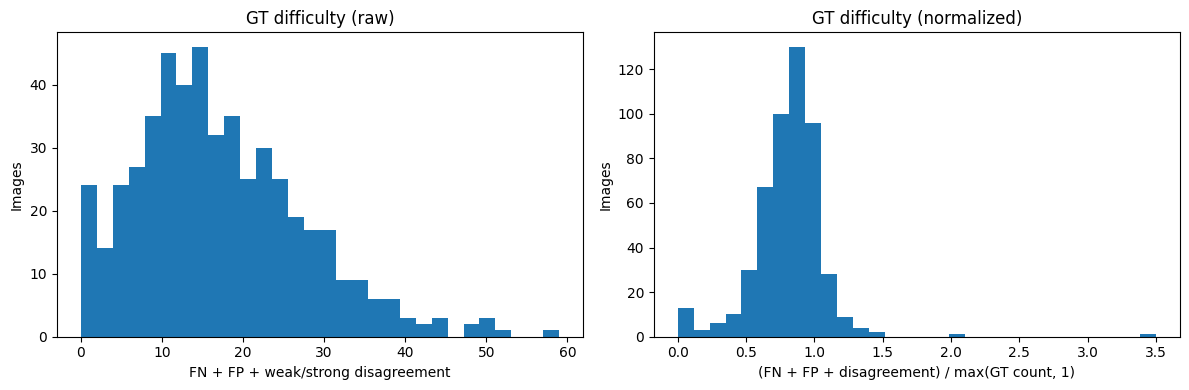

,count,mean,std,min,25%,50%,75%,max
gt_count,500.0,20.360000,11.380925,0.0,12.000000,19.000000,28.00,66.0
gt_fn_count,500.0,12.992000,8.708134,0.0,7.000000,12.000000,18.00,50.0
gt_fp_count,500.0,1.040000,1.548935,0.0,0.000000,1.000000,1.00,9.0
gt_ws_disagreement_count,500.0,2.934000,2.906982,0.0,1.000000,2.000000,4.00,20.0
gt_difficulty_raw,500.0,16.966000,10.505884,0.0,10.000000,15.000000,23.00,59.0
gt_difficulty_norm,500.0,0.811909,0.265491,0.0,0.692308,0.838919,0.95,3.5


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(image_df["gt_difficulty_raw"], bins=30)
axes[0].set_title("GT difficulty (raw)")
axes[0].set_xlabel("FN + FP + weak/strong disagreement")
axes[0].set_ylabel("Images")

axes[1].hist(image_df["gt_difficulty_norm"], bins=30)
axes[1].set_title("GT difficulty (normalized)")
axes[1].set_xlabel("(FN + FP + disagreement) / max(GT count, 1)")
axes[1].set_ylabel("Images")
plt.tight_layout()
plt.show()

image_df[["gt_count", "gt_fn_count", "gt_fp_count", "gt_ws_disagreement_count", "gt_difficulty_raw", "gt_difficulty_norm"]].describe().T


## C. Candidate no-GT proxy scores

We start with interpretable image-level proxies that use only model outputs:

### Confidence-based proxies
- prediction count
- mean confidence
- score standard deviation
- low-confidence count / fraction / mass

### Weak/strong disagreement proxies
- unmatched weak/strong prediction count / fraction
- mean weak/strong matched IoU gap
- mean weak/strong score difference
- class-disagreement count / fraction
- total weak/strong disagreement count

We do **not** use GT in any of these proxy definitions.

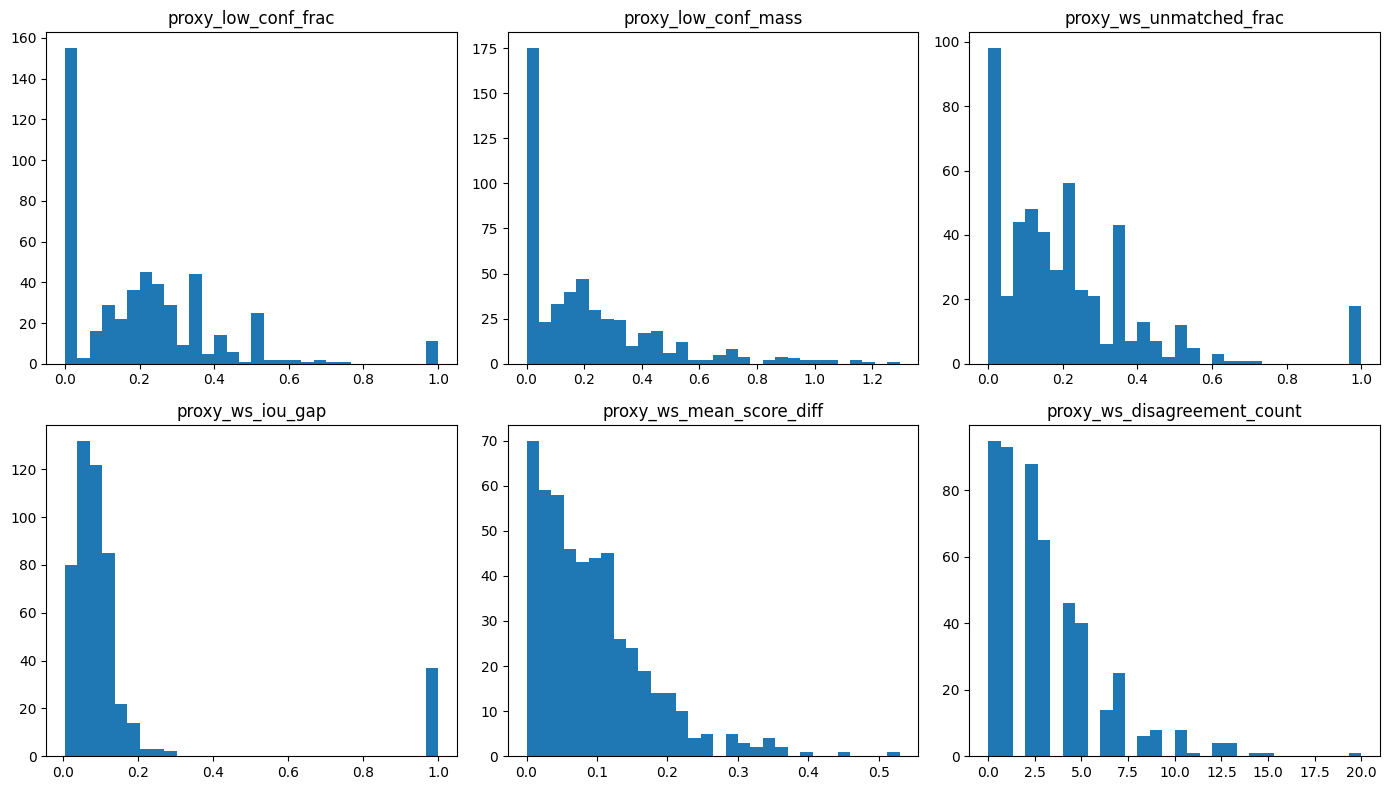

In [7]:
# Re-orient a few proxies so larger values consistently mean "harder image".
image_df["proxy_low_mean_score"] = 1.0 - image_df["proxy_mean_score"]

proxy_columns = [
    "proxy_pred_count",
    "proxy_low_mean_score",
    "proxy_score_std",
    "proxy_low_conf_count",
    "proxy_low_conf_frac",
    "proxy_low_conf_mass",
    "proxy_ws_unmatched_count",
    "proxy_ws_unmatched_frac",
    "proxy_ws_iou_gap",
    "proxy_ws_mean_score_diff",
    "proxy_ws_class_disagree_count",
    "proxy_ws_class_disagree_frac",
    "proxy_ws_disagreement_count",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
plot_cols = [
    "proxy_low_conf_frac",
    "proxy_low_conf_mass",
    "proxy_ws_unmatched_frac",
    "proxy_ws_iou_gap",
    "proxy_ws_mean_score_diff",
    "proxy_ws_disagreement_count",
]
for ax, col in zip(axes.flat, plot_cols):
    ax.hist(image_df[col], bins=30)
    ax.set_title(col)
plt.tight_layout()
plt.show()


## D. Correlate each proxy with GT difficulty

The main comparison metric is **Spearman rank correlation (SROCC)**. This is the most natural first check here because later we care about ranking images by difficulty more than fitting an exact regression target.

We report SROCC against:
- `gt_difficulty_raw`
- `gt_difficulty_norm`
- `gt_fn_count`
- `gt_fp_count`
- `gt_ws_disagreement_count`

In [8]:
correlation_rows = []
for proxy_col in proxy_columns:
    correlation_rows.append(
        {
            "proxy": proxy_col,
            "srocc_gt_raw": spearman_corr(image_df[proxy_col], image_df["gt_difficulty_raw"]),
            "srocc_gt_norm": spearman_corr(image_df[proxy_col], image_df["gt_difficulty_norm"]),
            "srocc_fn": spearman_corr(image_df[proxy_col], image_df["gt_fn_count"]),
            "srocc_fp": spearman_corr(image_df[proxy_col], image_df["gt_fp_count"]),
            "srocc_ws": spearman_corr(image_df[proxy_col], image_df["gt_ws_disagreement_count"]),
        }
    )

correlation_df = pd.DataFrame(correlation_rows).sort_values("srocc_gt_norm", ascending=False)
correlation_df


,proxy,srocc_gt_raw,srocc_gt_norm,srocc_fn,srocc_fp,srocc_ws
7,proxy_ws_unmatched_frac,0.351045,0.570944,0.179275,0.232833,0.696136
1,proxy_low_mean_score,0.156698,0.408369,0.048976,0.300053,0.263689
12,proxy_ws_disagreement_count,0.601639,0.321570,0.320766,0.575300,1.000000
6,proxy_ws_unmatched_count,0.597339,0.307235,0.318345,0.567013,0.993965
4,proxy_low_conf_frac,0.353547,0.260173,0.223450,0.445797,0.457483
8,proxy_ws_iou_gap,0.145971,0.215193,0.072078,0.156863,0.230725
11,proxy_ws_class_disagree_frac,0.209349,0.200618,0.108736,0.235569,0.293863
10,proxy_ws_class_disagree_count,0.215494,0.194588,0.113392,0.241542,0.299371
5,proxy_low_conf_mass,0.494818,0.134642,0.282561,0.657078,0.674234
3,proxy_low_conf_count,0.542050,0.126890,0.326258,0.654228,0.704544


## E. Weak/strong agreement distributions

These plots are useful both as direct diagnostics and as context for the disagreement-based proxies.

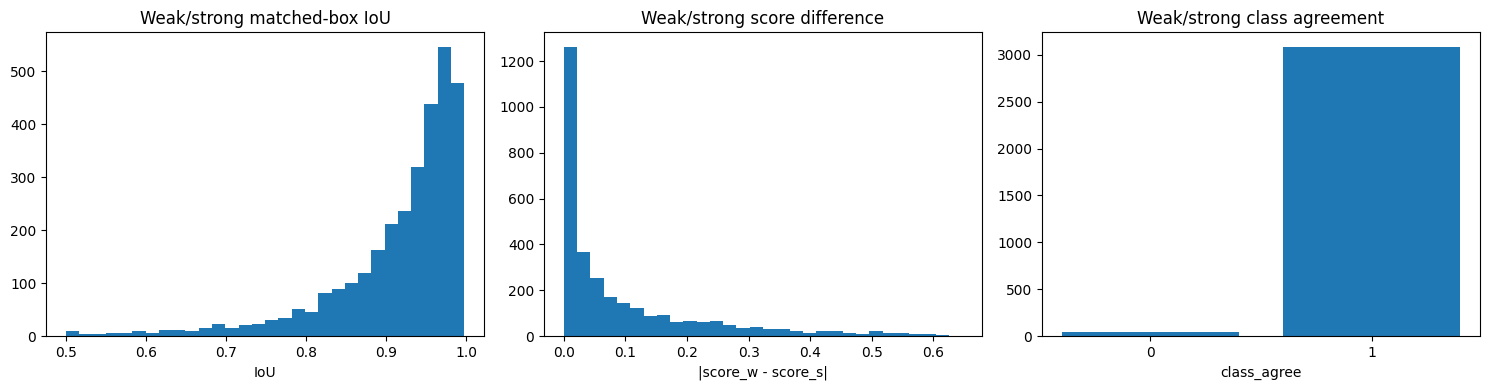

In [9]:
if len(ws_df):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].hist(ws_df["iou"], bins=30)
    axes[0].set_title("Weak/strong matched-box IoU")
    axes[0].set_xlabel("IoU")

    axes[1].hist(ws_df["score_diff"], bins=30)
    axes[1].set_title("Weak/strong score difference")
    axes[1].set_xlabel("|score_w - score_s|")

    axes[2].hist(ws_df["class_agree"], bins=[-0.5, 0.5, 1.5], rwidth=0.8)
    axes[2].set_xticks([0, 1])
    axes[2].set_title("Weak/strong class agreement")
    axes[2].set_xlabel("class_agree")
    plt.tight_layout()
    plt.show()

    pd.DataFrame({
        "mean_matched_iou": [ws_df["iou"].mean()],
        "mean_score_diff": [ws_df["score_diff"].mean()],
        "class_agreement_rate": [ws_df["class_agree"].mean()],
        "num_matches": [len(ws_df)],
    })
else:
    print("No weak/strong matches were found at the current thresholds.")


## F. Scatter plots for the strongest single proxies

To keep the notebook readable, we only plot the top few single proxies ranked by SROCC with the normalized GT difficulty target.

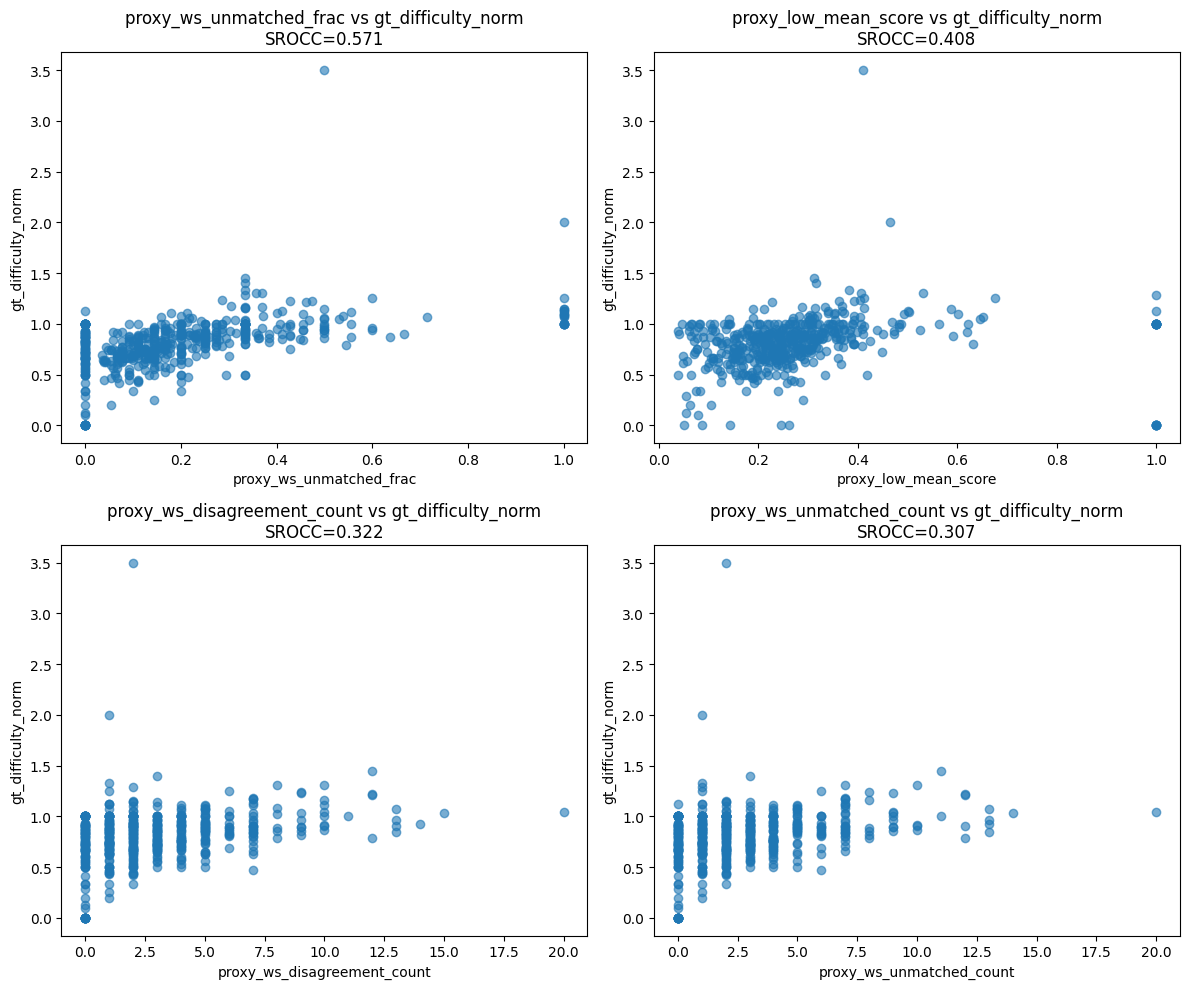

In [10]:
top_proxy_names = correlation_df.head(NUM_SCATTER_PLOTS)["proxy"].tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, proxy_col in zip(axes.flat, top_proxy_names):
    ax.scatter(image_df[proxy_col], image_df["gt_difficulty_norm"], alpha=0.6)
    ax.set_xlabel(proxy_col)
    ax.set_ylabel("gt_difficulty_norm")
    score = correlation_df.loc[correlation_df["proxy"] == proxy_col, "srocc_gt_norm"].iloc[0]
    ax.set_title(f"{proxy_col} vs gt_difficulty_norm\nSROCC={score:.3f}")
plt.tight_layout()
plt.show()


## G. Try a few simple proxy combinations

We keep combinations deliberately interpretable. Each one is an average of z-scored component proxies so that no single raw scale dominates just because of units.

The combinations below are meant as simple baselines, not a final method.

In [11]:
image_df["proxy_combo_confidence"] = (
    zscore(image_df["proxy_low_conf_frac"])
    + zscore(image_df["proxy_low_conf_mass"])
    + zscore(image_df["proxy_low_mean_score"])
) / 3.0

image_df["proxy_combo_views"] = (
    zscore(image_df["proxy_ws_unmatched_frac"])
    + zscore(image_df["proxy_ws_iou_gap"])
    + zscore(image_df["proxy_ws_mean_score_diff"])
    + zscore(image_df["proxy_ws_class_disagree_frac"])
) / 4.0

image_df["proxy_combo_hybrid"] = (
    zscore(image_df["proxy_low_conf_mass"])
    + zscore(image_df["proxy_low_conf_frac"])
    + zscore(image_df["proxy_ws_unmatched_frac"])
    + zscore(image_df["proxy_ws_iou_gap"])
    + zscore(image_df["proxy_ws_mean_score_diff"])
) / 5.0

combo_columns = [
    "proxy_combo_confidence",
    "proxy_combo_views",
    "proxy_combo_hybrid",
]

combo_rows = []
for proxy_col in combo_columns:
    combo_rows.append(
        {
            "proxy": proxy_col,
            "srocc_gt_raw": spearman_corr(image_df[proxy_col], image_df["gt_difficulty_raw"]),
            "srocc_gt_norm": spearman_corr(image_df[proxy_col], image_df["gt_difficulty_norm"]),
            "srocc_fn": spearman_corr(image_df[proxy_col], image_df["gt_fn_count"]),
            "srocc_fp": spearman_corr(image_df[proxy_col], image_df["gt_fp_count"]),
            "srocc_ws": spearman_corr(image_df[proxy_col], image_df["gt_ws_disagreement_count"]),
        }
    )
combo_df = pd.DataFrame(combo_rows).sort_values("srocc_gt_norm", ascending=False)
combo_df


,proxy,srocc_gt_raw,srocc_gt_norm,srocc_fn,srocc_fp,srocc_ws
1,proxy_combo_views,0.169822,0.466835,0.043338,0.132901,0.425730
2,proxy_combo_hybrid,0.354598,0.458229,0.169703,0.416248,0.604072
0,proxy_combo_confidence,0.298213,0.316392,0.140417,0.466717,0.432144


## H. Compare single proxies and combinations

This summary table puts the strongest single proxies next to the simple combined proxies so we can see whether the combinations actually help.

In [12]:
top_single_df = correlation_df.head(8).copy()
summary_df = pd.concat([top_single_df, combo_df], ignore_index=True).sort_values("srocc_gt_norm", ascending=False)
summary_df


,proxy,srocc_gt_raw,srocc_gt_norm,srocc_fn,srocc_fp,srocc_ws
0,proxy_ws_unmatched_frac,0.351045,0.570944,0.179275,0.232833,0.696136
8,proxy_combo_views,0.169822,0.466835,0.043338,0.132901,0.425730
9,proxy_combo_hybrid,0.354598,0.458229,0.169703,0.416248,0.604072
1,proxy_low_mean_score,0.156698,0.408369,0.048976,0.300053,0.263689
2,proxy_ws_disagreement_count,0.601639,0.321570,0.320766,0.575300,1.000000
10,proxy_combo_confidence,0.298213,0.316392,0.140417,0.466717,0.432144
3,proxy_ws_unmatched_count,0.597339,0.307235,0.318345,0.567013,0.993965
4,proxy_low_conf_frac,0.353547,0.260173,0.223450,0.445797,0.457483
5,proxy_ws_iou_gap,0.145971,0.215193,0.072078,0.156863,0.230725
6,proxy_ws_class_disagree_frac,0.209349,0.200618,0.108736,0.235569,0.293863


## I. Hardest-image examples

A rank-based proxy can look good numerically but still be hard to interpret. To ground the correlation results, we inspect a few of the hardest images by normalized GT difficulty and overlay GT boxes plus original-view predictions.

In [13]:
hardest_df = image_df.sort_values("gt_difficulty_norm", ascending=False).head(NUM_HARDEST_EXAMPLES)
hardest_df[[
    "sample_id",
    "gt_count",
    "gt_fn_count",
    "gt_fp_count",
    "gt_ws_disagreement_count",
    "gt_difficulty_raw",
    "gt_difficulty_norm",
    "proxy_combo_hybrid",
]]


,sample_id,gt_count,gt_fn_count,gt_fp_count,gt_ws_disagreement_count,gt_difficulty_raw,gt_difficulty_norm,proxy_combo_hybrid
298,target_val:lindau:lindau_000031_000019:beta=0.02,2.0,2.0,3.0,2.0,7.0,3.50,0.228725
284,target_val:lindau:lindau_000017_000019:beta=0.02,0.0,0.0,1.0,1.0,2.0,2.00,0.843111
29,target_val:frankfurt:frankfurt_000000_012868:b...,20.0,8.0,9.0,12.0,29.0,1.45,0.525011
228,target_val:frankfurt:frankfurt_000001_066092:b...,5.0,2.0,2.0,3.0,7.0,1.40,0.228339


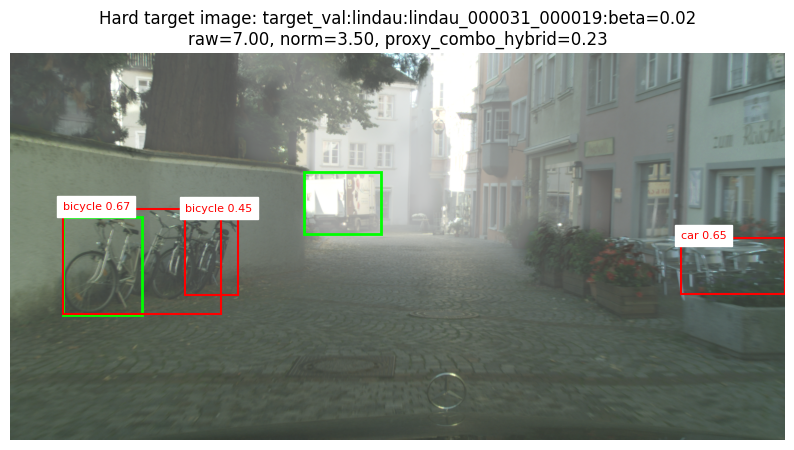

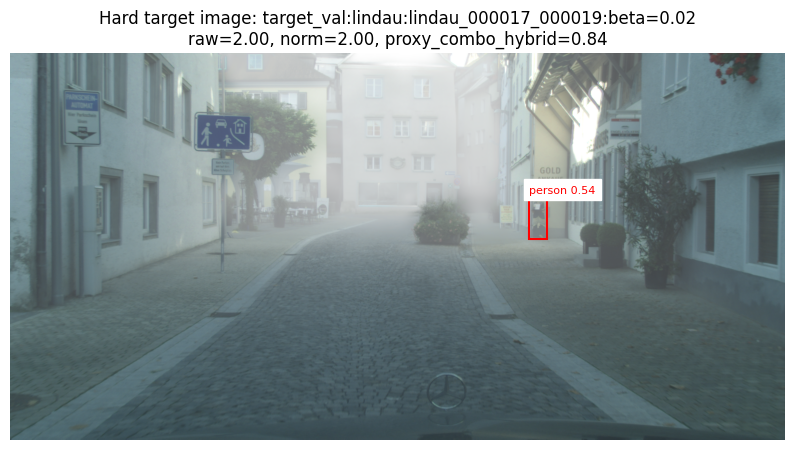

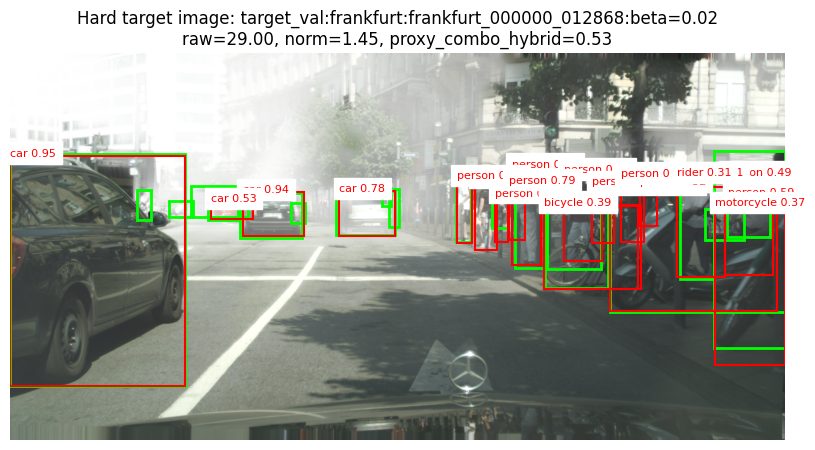

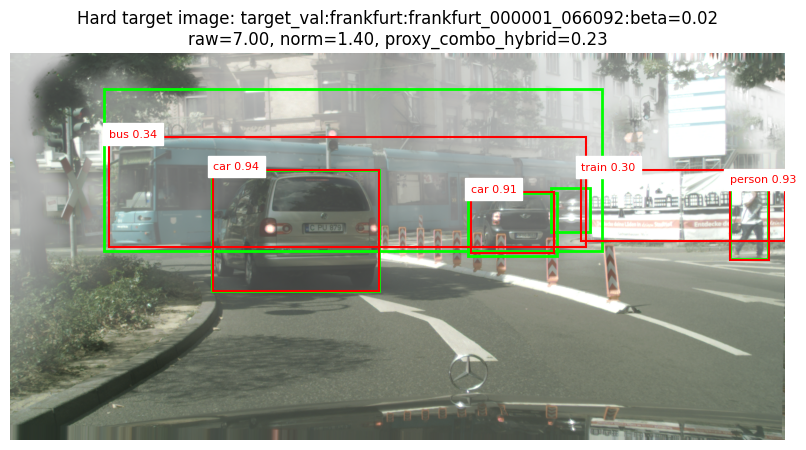

In [14]:
for _, row in hardest_df.iterrows():
    show_image_with_gt_and_preds(row, image_cache, title_prefix="Hard target image: ")


## J. Final quick take

The table below is a compact end-of-notebook summary of the strongest signals found here. It is the part most likely to feed the next DAOD design step.

In [15]:
best_single = correlation_df.iloc[0]
best_combo = combo_df.iloc[0]

pd.DataFrame(
    [
        {
            "type": "best_single",
            "proxy": best_single["proxy"],
            "srocc_gt_norm": best_single["srocc_gt_norm"],
            "srocc_gt_raw": best_single["srocc_gt_raw"],
        },
        {
            "type": "best_combo",
            "proxy": best_combo["proxy"],
            "srocc_gt_norm": best_combo["srocc_gt_norm"],
            "srocc_gt_raw": best_combo["srocc_gt_raw"],
        },
    ]
)


,type,proxy,srocc_gt_norm,srocc_gt_raw
0,best_single,proxy_ws_unmatched_frac,0.570944,0.351045
1,best_combo,proxy_combo_views,0.466835,0.169822
